In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
np.random.seed(42)

df = pd.read_csv("data/health_study_dataset.csv")

df_mask = ["age", "weight", "height", "systolic_bp", "cholesterol"]
df[df_mask].mean()

age             49.426250
weight          73.413000
height         171.849250
systolic_bp    149.178625
cholesterol      4.929150
dtype: float64

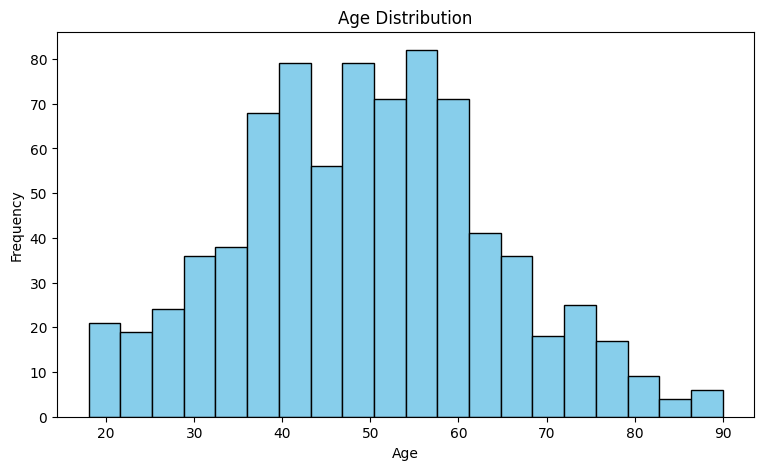

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.show()

Shows the distribution of ages

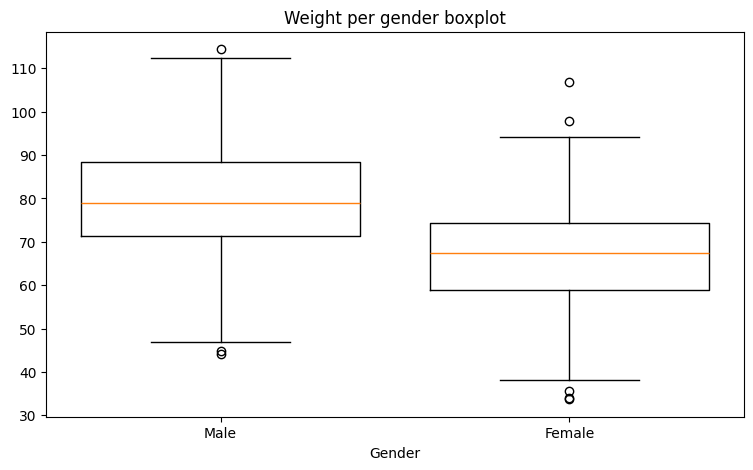

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df[df["sex"] == "M"]["weight"],
			df[df["sex"] == "F"]["weight"]],
			tick_labels=["Male", "Female"],
			widths=0.8)
ax.set_title("Weight per gender boxplot")
ax.set_xlabel("Gender")
plt.show()

Shows the weight per gender. Dots outside are outliers.

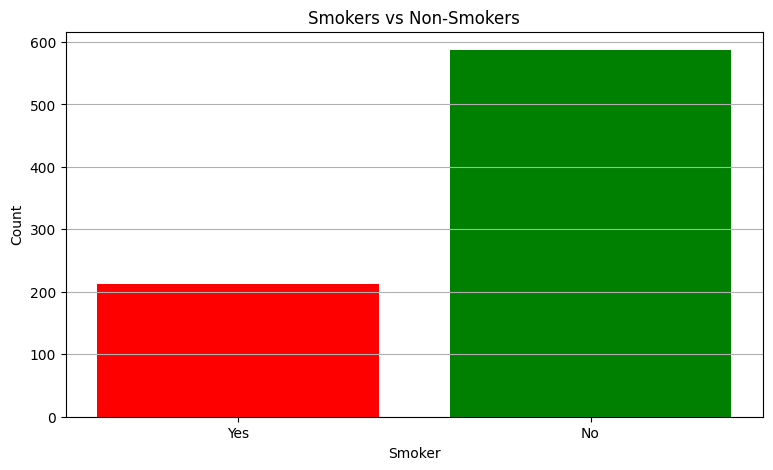

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

x = ["Yes", "No"]
y = [df[df["smoker"] == "Yes"]["smoker"].count(), df[df["smoker"] == "No"]["smoker"].count()]

ax.bar(x, y, color=["red", "green"])
ax.set_title("Smokers vs Non-Smokers")
ax.set_xlabel("Smoker")
ax.set_ylabel("Count")
ax.grid(axis="y")
plt.show()

Compares the amount of smokers vs non-smokers.

In [5]:
# Calculating number of sick and healthy individuals and sick rate
actual_sick = df[df["disease"] == 1]["systolic_bp"].count()
actual_healthy = df[df["disease"] == 0]["systolic_bp"].count()
actual_sick_rate = actual_sick / df.__len__()
print(actual_sick, actual_healthy, actual_sick_rate)

47 753 0.05875


Calculates the true count of sick vs healthy people and the sick rate of those.

In [6]:
# Simulate 1000 people with the same sick rate
n = 1000

sim_df = pd.DataFrame()
sim_df["id"] = range(1, n + 1)
sim_df["age"] = np.random.normal(df["age"].mean(), df["age"].std(), n).round().astype(int)
sim_df["sex"] = np.random.choice(["M", "F"], n)
sim_df["weight"] = np.random.normal(df["weight"].mean(), df["weight"].std(), n).round(1)
sim_df["height"] = np.random.normal(df["height"].mean(), df["height"].std(), n).round(1)
sim_df["systolic_bp"] = np.random.normal(df["systolic_bp"].mean(), df["systolic_bp"].std(), n).round().astype(float)
sim_df["cholesterol"] = np.random.normal(df["cholesterol"].mean(), df["cholesterol"].std(), n).round().astype(float)
sim_df["smoker"] = np.random.choice(["Yes", "No"], n)
sim_df["disease"] = np.random.choice([1, 0], n, p=[actual_sick_rate, 1 - actual_sick_rate])


In [7]:
# Sampling distribution of sickness rate
def sample_mean(_n, _sim_df) -> float:
	"""
	Calculates the sample mean of size _n from the population _pop
	Args:
		_n (int): Sample size
		_pop (array-like): Population
	Returns:
		float: Sample mean
	"""
	return np.mean(np.random.choice(_sim_df, size=_n, replace=False))

# How many sample means to calculate
R = 5000
means_n50 = np.array([sample_mean(50, sim_df["disease"]) for _ in range(R)])
means_n200 = np.array([sample_mean(200, sim_df["disease"]) for _ in range(R)])


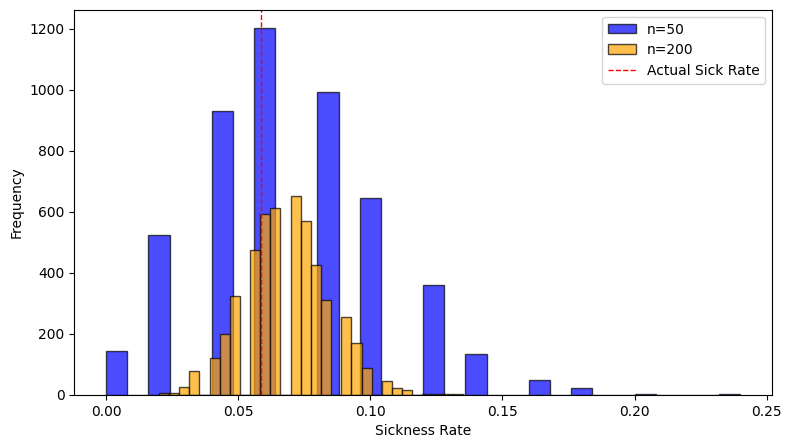

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(means_n50, bins=30, alpha=0.7, label="n=50", color="blue", edgecolor="black")
ax.hist(means_n200, bins=30, alpha=0.7, label="n=200", color="orange", edgecolor="black")
ax.set_xlabel("Sickness Rate")
ax.set_ylabel("Frequency")
ax.axvline(actual_sick_rate, color="red", linestyle="dashed", linewidth=1, label="Actual Sick Rate")
ax.legend()
plt.show()

Compares the sick rate of a simulated population of 1000 with the true sick rate
We see that the simulated sick rate is shifted to the right of the true sick rate. This is likely due to our small simulated population that give rise to bigger fluctuations. If a larger simulated population size was used the simulated sick rate would get close to the true sick rate.